In [481]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

### №1 - Сбор датасета

In [482]:
np.random.seed(42)
n_samples = 200

area = np.random.normal(70, 20, n_samples).round(1)  # Площадь в кв.м.
area = np.clip(area, 25, 150)
dist_metro = np.random.exponential(1.5, n_samples).round(1)  # До метро в км
renovation = np.random.choice(["None", "Cosmetic", "Euro"], n_samples, p=[0.3, 0.5, 0.2])

In [483]:
price = (
    50
    + area * 2.5
    - dist_metro * 10
    + np.where(renovation == "Cosmetic", 15, np.where(renovation == "Euro", 40, 0))
    + np.random.normal(0, 15, n_samples)
)
price = price.round(1)

In [484]:
dist_metro[np.random.choice([True, False], n_samples, p=[0.05, 0.95])] = np.nan  # Пропуски
renovation = renovation.astype(object)
renovation[np.random.choice([True, False], n_samples, p=[0.04, 0.96])] = None  # Пропуски

price[10] = 650.0  # Выброс: огромная цена для маленькой квартиры
area[20] = -45.0  # Ошибка ввода: отрицательная площадь

# Собираем DataFrame
df = pd.DataFrame(
    {
        "Area_Sqm": area,
        "Dist_Metro_Km": dist_metro,
        "Renovation": renovation,
        "Price_K_USD": price,
    }
)

# Добавляем дубликаты строк
df = pd.concat([df, df.iloc[[5, 12]]], ignore_index=True)
print("Датасет готов к EDA и регрессии! Размер таблицы:", df.shape)

Датасет готов к EDA и регрессии! Размер таблицы: (202, 4)


### №2 - Начальная обработка датасета

In [485]:
print("Вид датасета")
print(df.tail())
print(df['Renovation'].unique())

print("="*100,"\n")
print("Краткая информация по датасету")
df.info()


Вид датасета
     Area_Sqm  Dist_Metro_Km Renovation  Price_K_USD
197      73.1            1.6       Euro        272.5
198      71.2            2.1   Cosmetic        211.4
199      47.1            1.3       None        133.6
200      65.3            0.5       Euro        235.8
201      74.8            2.4       None        220.5
<StringArray>
['Euro', 'Cosmetic', 'None', nan]
Length: 4, dtype: str

Краткая информация по датасету
<class 'pandas.DataFrame'>
RangeIndex: 202 entries, 0 to 201
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Area_Sqm       202 non-null    float64
 1   Dist_Metro_Km  190 non-null    float64
 2   Renovation     191 non-null    str    
 3   Price_K_USD    202 non-null    float64
dtypes: float64(3), str(1)
memory usage: 6.4 KB


In [486]:
print("Количество пустых ячеек")
print(df.isna().sum())

print("="*100,"\n")
print("Количество дубликатов")
print(df.duplicated().reset_index())

print("="*100,"\n")
print("Проверка на аномалии")
df.describe()

Количество пустых ячеек
Area_Sqm          0
Dist_Metro_Km    12
Renovation       11
Price_K_USD       0
dtype: int64

Количество дубликатов
     index      0
0        0  False
1        1  False
2        2  False
3        3  False
4        4  False
..     ...    ...
197    197  False
198    198  False
199    199  False
200    200   True
201    201   True

[202 rows x 2 columns]

Проверка на аномалии


,Area_Sqm,Dist_Metro_Km,Price_K_USD
count,202.000000,190.000000,202.000000
mean,68.514851,1.428947,225.835149
std,19.996357,1.357306,62.163930
min,-45.000000,0.000000,80.100000
25%,55.775000,0.425000,186.225000
50%,69.600000,1.100000,225.150000
75%,79.575000,2.100000,261.900000
max,124.400000,7.000000,650.000000


In [487]:
df_cleaned = df.drop_duplicates().reset_index(drop=True)
df_cleaned = df_cleaned[df_cleaned['Area_Sqm']>0]
df_cleaned = df_cleaned[df_cleaned['Price_K_USD']<500]


Median_metro = df_cleaned['Dist_Metro_Km'].median()

df_cleaned['Dist_Metro_Km'] = df_cleaned['Dist_Metro_Km'].fillna(Median_metro)

renovation_mode = df_cleaned['Renovation'].mode()[0]
df_cleaned['Renovation'] = df_cleaned['Renovation'].fillna(renovation_mode)

renovation_dict = {'None':0, 'Euro':1 , 'Cosmetic':2}

df_cleaned["Renovation"] = df_cleaned["Renovation"].astype("category")
df_cleaned["Renovation_code"] = df_cleaned["Renovation"].map(renovation_dict)
df_cleaned["Renovation_code"] = df_cleaned["Renovation_code"].astype("int")

print(df_cleaned.head())

print("Количество пропусков после обработки")
print(df_cleaned.isna().sum(),'\n')

print("Количество дубликатов после обработки")
print(df_cleaned.duplicated().sum())

df_cleaned.describe()

print(df_cleaned.head())

   Area_Sqm  Dist_Metro_Km Renovation  Price_K_USD  Renovation_code
0      79.9            3.1       Euro        249.0                1
1      67.2            2.0   Cosmetic        205.7                2
2      83.0            1.8       None        230.6                0
3     100.5            1.8       Euro        310.3                1
4      65.3            0.7       None        207.0                0
Количество пропусков после обработки
Area_Sqm           0
Dist_Metro_Km      0
Renovation         0
Price_K_USD        0
Renovation_code    0
dtype: int64 

Количество дубликатов после обработки
0
   Area_Sqm  Dist_Metro_Km Renovation  Price_K_USD  Renovation_code
0      79.9            3.1       Euro        249.0                1
1      67.2            2.0   Cosmetic        205.7                2
2      83.0            1.8       None        230.6                0
3     100.5            1.8       Euro        310.3                1
4      65.3            0.7       None        207.0     

## №3 - Построение базовых графиков

In [488]:
pocket = []

for k in range(int((min(df_cleaned['Price_K_USD'].unique().tolist())-(min(df_cleaned['Price_K_USD'].unique().tolist())%100))),int((max(df_cleaned['Price_K_USD'].unique().tolist())+(100-(max(df_cleaned['Price_K_USD'].unique().tolist())%100))))+1,100):
    if k not in pocket:
            pocket.append(k)

labels = ['0-100','100-200','200-300','300-400']

df_cleaned['Pocket_price'] = pd.cut(df_cleaned['Price_K_USD'],bins=pocket,labels=labels)

counts_price = df_cleaned['Pocket_price'].value_counts().sort_index()
counts_renovation = df_cleaned['Renovation'].value_counts().sort_index()
print(counts_renovation)

Renovation
Cosmetic    101
Euro         41
None         56
Name: count, dtype: int64


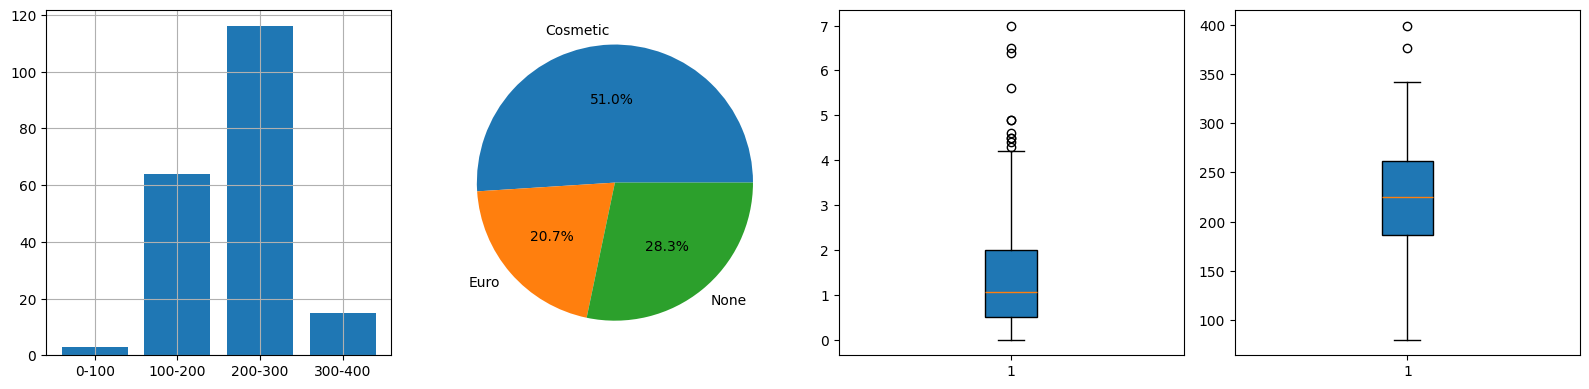

In [489]:
fig, (ax1,ax2,ax3,ax4) = plt.subplots(1,4, figsize = (16,4))

ax1.bar(counts_price.index.astype(str),counts_price.values)
ax1.set_title('')
ax1.grid(True)

ax2.pie(counts_renovation.values,labels=counts_renovation.index.astype(str),autopct='%1.1f%%')

ax3.boxplot(df_cleaned['Dist_Metro_Km'].dropna(),patch_artist=True)

ax4.boxplot(df_cleaned['Price_K_USD'].dropna(),patch_artist=True)

plt.tight_layout()
plt.show()



## №4 - Построение корреляционной матрицы и линейной регрессии

In [490]:
corr_matr = df_cleaned.select_dtypes(include=[np.number]).corr()
print(corr_matr)

                 Area_Sqm  Dist_Metro_Km  Price_K_USD  Renovation_code
Area_Sqm         1.000000      -0.047225     0.873948        -0.159767
Dist_Metro_Km   -0.047225       1.000000    -0.304840        -0.018204
Price_K_USD      0.873948      -0.304840     1.000000        -0.008234
Renovation_code -0.159767      -0.018204    -0.008234         1.000000


In [491]:
df_linear = pd.DataFrame()
df_linear = df_cleaned[['Area_Sqm', 'Dist_Metro_Km', 'Price_K_USD', 'Renovation_code']].copy()
df_linear

,Area_Sqm,Dist_Metro_Km,Price_K_USD,Renovation_code
0,79.9,3.1,249.0,1
1,67.2,2.0,205.7,2
2,83.0,1.8,230.6,0
3,100.5,1.8,310.3,1
4,65.3,0.7,207.0,0
...,...,...,...,...
195,77.7,0.2,254.5,2
196,52.3,0.2,185.9,2
197,73.1,1.6,272.5,1
198,71.2,2.1,211.4,2


In [502]:
x = df_linear.drop(columns=["Price_K_USD"])
y = df_linear["Price_K_USD"]

X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

model = LinearRegression()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)
r2 = r2_score(y_test,y_pred)

mse = mean_squared_error(y_test,y_pred)

rmse = mean_squared_error(y_test,y_pred)**0.5

print(f"Коэффициент детерминации R2: {r2}")
print(f"Средняя квадратичная ошибка MSE: {mse}")
print(f"Корень средней квадратичной ошибки RMSE: {rmse}")

print("\n")

for feature, coef in zip(x.columns, model.coef_):
    print(f"Признак '{feature}': {coef:.2f}")

print(f"Свободный член (Intercept): {model.intercept_:.2f}")

print(f"Итоговая формула для линейной регрессии:\n Y = {x.columns[0]}*{model.coef_[0]:.2f} + {x.columns[1]}*({model.coef_[1]:.2f}) + {x.columns[2]}*{model.coef_[2]:.2f} + {model.intercept_:.2f}")

Коэффициент детерминации R2: 0.8682048441786451
Средняя квадратичная ошибка MSE: 378.63104040534427
Корень средней квадратичной ошибки RMSE: 19.458443935868672


Признак 'Area_Sqm': 2.55
Признак 'Dist_Metro_Km': -10.61
Признак 'Renovation_code': 7.61
Свободный член (Intercept): 52.68
Итоговая формула для линейной регрессии:
 Y = Area_Sqm*2.55 + Dist_Metro_Km*(-10.61) + Renovation_code*7.61 + 52.68
